In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect("../data/processed/cosmere.db")

def sql_query(query):
    
    result = pd.read_sql_query(query, conn)
   
    return result

In [22]:
df = pd.read_sql_query("SELECT * from books", conn)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             19 non-null     str    
 1   series            19 non-null     str    
 2   series_order      19 non-null     int64  
 3   hardcover_id      19 non-null     int64  
 4   release_year      19 non-null     int64  
 5   pages             19 non-null     int64  
 6   rating            19 non-null     float64
 7   ratings_count     19 non-null     int64  
 8   reviews_count     19 non-null     int64  
 9   users_read_count  19 non-null     int64  
 10  has_audiobook     19 non-null     int64  
 11  has_ebook         19 non-null     int64  
 12  genres            19 non-null     str    
 13  moods             19 non-null     str    
 14  content_warnings  19 non-null     str    
 15  description       19 non-null     str    
dtypes: float64(1), int64(9), str(6)
memory usage: 2.5 KB


In [23]:
df['has_audiobook'] = df['has_audiobook'].astype(bool)
df['has_ebook'] = df['has_ebook'].astype(bool)

In [24]:
df['genres'] = df['genres'].str.split('|')
df['moods'] = df['moods'].str.split('|')

In [25]:
df[['title', 'genres', 'moods', 'has_audiobook']].head()

,title,genres,moods,has_audiobook
0,Mistborn: The Final Empire,"[Fantasy, Adventure, Young Adult, Fiction, Hig...","[Adventurous, mysterious, dark, tense, emotion...",True
1,The Well of Ascension,"[Fantasy, Fiction, Adventure, Dystopian, Epic ...","[Adventurous, mysterious, tense, dark, emotion...",True
2,The Hero of Ages,"[Fantasy, Fiction, Adventure, Dystopian, Ficti...","[Adventurous, emotional, tense, dark, mysterio...",True
3,The Alloy of Law,"[Fantasy, Science Fiction, Fiction, Retail, Ad...","[Adventurous, mysterious, funny, tense, lighth...",True
4,Shadows of Self,"[Fantasy, Science Fiction, Fiction, Imaginary ...","[Adventurous, mysterious, funny, emotional, te...",True


In [26]:
df["moods"] = df["moods"].apply(lambda moods: [mood.strip('"[]').lower() for mood in moods if not mood.isdigit()])

In [27]:
mood_counts = df["moods"].explode().value_counts()

In [28]:
mood_counts

moods
adventurous     20
tense           20
emotional       20
mysterious      18
hopeful         18
reflective      17
dark            16
inspiring       16
challenging     16
funny           13
sad             12
lighthearted    11
informative      6
relaxing         4
medium-paced     3
fast-paced       2
exciting         1
intense          1
romantic         1
surprising       1
Name: count, dtype: int64

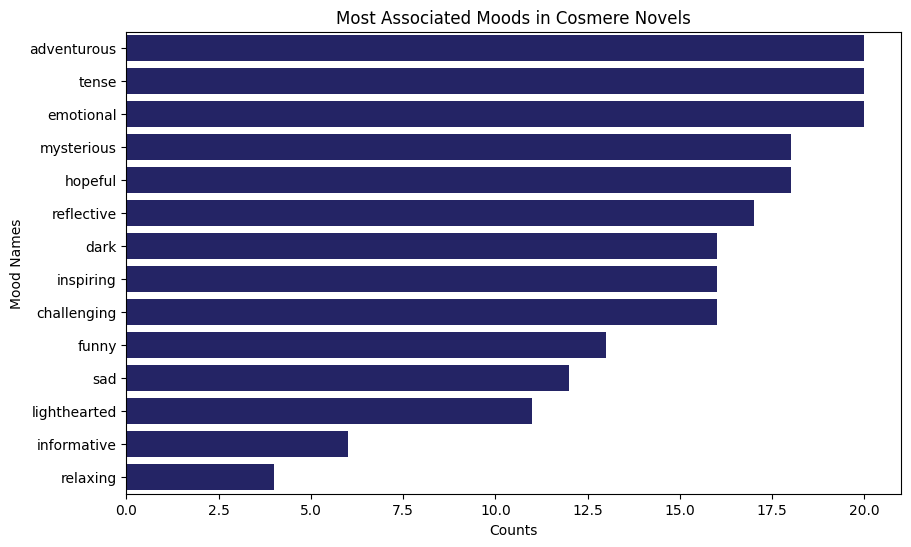

In [ ]:
mood_counts_filtered = mood_counts[mood_counts > 3]

plt.figure(figsize=(10, 6))
sns.barplot(x=mood_counts_filtered.values, y=mood_counts_filtered.index, color="midnightblue")
plt.xlabel("Counts")
plt.ylabel("Mood Names")
plt.title("Moods most Associated with Cosmere Novels")
plt.show()

In [46]:
df[["title", "pages"]]

,title,pages
0,Mistborn: The Final Empire,541
1,The Well of Ascension,590
2,The Hero of Ages,572
3,The Alloy of Law,325
4,Shadows of Self,376
5,The Bands of Mourning,455
6,The Lost Metal,507
7,The Way of Kings,1007
8,Words of Radiance,1088
9,Oathbringer,1243


In [49]:
df["story_type"] = np.where((df["pages"] <200),"short story", "novel")

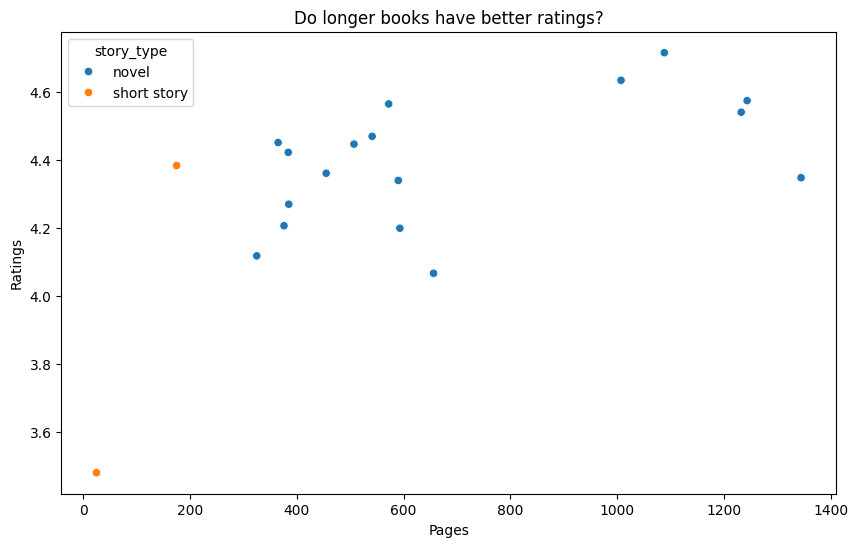

In [50]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["pages"], y=df["rating"], hue=df["story_type"])
plt.xlabel("Pages")
plt.ylabel("Ratings")
plt.title("Do longer books have better ratings?")
plt.show()

In [54]:
novel_df = df[df["story_type"]=="novel"]
novel_df

,title,series,series_order,hardcover_id,release_year,pages,rating,ratings_count,reviews_count,users_read_count,has_audiobook,has_ebook,genres,moods,content_warnings,description,story_type
0,Mistborn: The Final Empire,Mistborn Era 1,1,369692,2006,541,4.4689,3941,395,5312,True,True,"[Fantasy, Adventure, Young Adult, Fiction, Hig...","[adventurous, mysterious, dark, tense, emotion...",Violence|Slavery|Classism|Rape|Physical abuse|...,For a thousand years the ash fell and no flowe...,novel
1,The Well of Ascension,Mistborn Era 1,2,427383,2007,590,4.3391,3005,253,4206,True,True,"[Fantasy, Fiction, Adventure, Dystopian, Epic ...","[adventurous, mysterious, tense, dark, emotion...",Injury/Injury detail|Death|War|Violence|Blood|...,From #1 New York Times bestselling author Bran...,novel
2,The Hero of Ages,Mistborn Era 1,3,103241,2007,572,4.5641,2785,249,3846,True,True,"[Fantasy, Fiction, Adventure, Dystopian, Ficti...","[adventurous, emotional, tense, dark, mysterio...",Torture|body horror|Death|Blood|Murder|Genocid...,"To end the Final Empire and restore freedom, V...",novel
3,The Alloy of Law,Mistborn Era 2,1,330249,2011,325,4.1172,1629,138,2357,True,True,"[Fantasy, Science Fiction, Fiction, Retail, Ad...","[adventurous, mysterious, funny, tense, lighth...",,"""Three hundred years after the events of the M...",novel
4,Shadows of Self,Mistborn Era 2,2,135725,2015,376,4.2059,1327,101,2007,True,True,"[Fantasy, Science Fiction, Fiction, Imaginary ...","[adventurous, mysterious, funny, emotional, te...",,Shadows of Self shows Mistborn’s society evolv...,novel
5,The Bands of Mourning,Mistborn Era 2,3,427966,2016,455,4.3603,1242,97,1889,True,True,"[Fantasy, Science Fiction, Fiction, Literature...","[adventurous, mysterious, funny, emotional, te...",Child abuse|child death|Death,Three hundred years after the events of the Mi...,novel
6,The Lost Metal,Mistborn Era 2,4,427863,2022,507,4.4460,908,83,1439,True,True,"[Adventure, Fantasy, Fiction, Science Fiction,...","[adventurous, challenging, dark, emotional, fa...",Alcoholism|Blood|Death|Gun violence|Murder,"For years, frontier lawman turned big-city sen...",novel
7,The Way of Kings,Stormlight Archive,1,386446,2010,1007,4.6337,2972,321,4045,True,True,"[Adulte, Adventure, Aventure, Fantasy, Fiction...","[emotional, tense, adventurous, adventurous, c...",Ab|Alcohol|Animal cruelty|Blood|Death|Death of...,From #1 New York Times bestselling author Bran...,novel
8,Words of Radiance,Stormlight Archive,2,374131,2012,1088,4.7148,2423,206,3381,True,True,"[Adventure, Epic Fantasy, Fantasy, Fiction, Hi...","[adventurous, challenging, dark, emotional, fu...",Alcohol|Animal cruelty|Child abuse|Death|Death...,Expected by his enemies to die the miserable d...,novel
9,Oathbringer,Stormlight Archive,3,459452,2017,1243,4.5739,1882,150,2760,True,True,"[Fantasy, Fiction, Science Fiction, War, Ficti...","[adventurous, emotional, tense, inspiring, mys...",,"In Oathbringer, the third volume of the New Yo...",novel


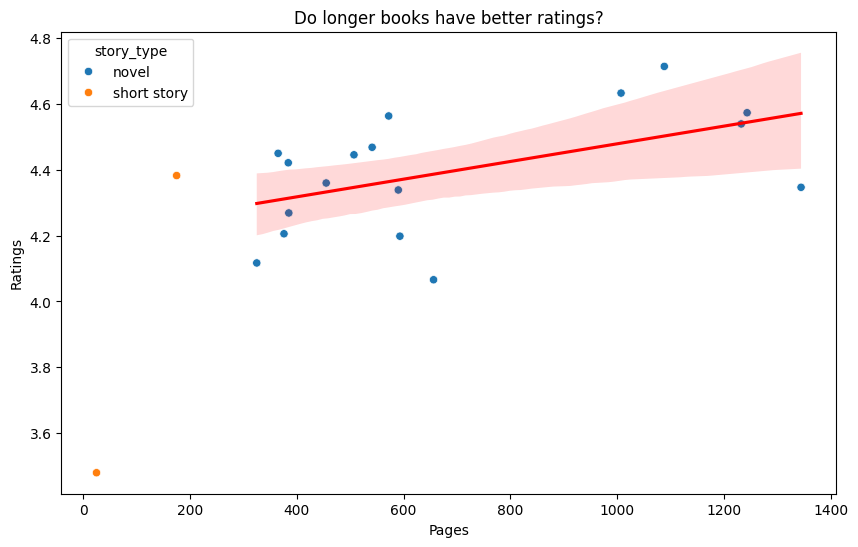

In [55]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["pages"], y=df["rating"], hue=df["story_type"])
sns.regplot(x=novel_df["pages"], y=novel_df["rating"], scatter = False, color = "red")
plt.xlabel("Pages")
plt.ylabel("Ratings")
plt.title("Do longer books have better ratings?")
plt.show()